https://medium.com/strava-engineering/an-improved-gap-model-8b07ae8886c3


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mgpoirot/utmb-world-race-daa")

print("Path to dataset files:", path)

/usr/local/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /root/.cache/kagglehub/datasets/mgpoirot/utmb-world-race-daa/versions/6


In [2]:
import os
import pandas as pd

# list files
files = os.listdir(path)
print("Files in dataset:", files)

# załóżmy, że jest CSV
for f in files:
    if f.endswith(".csv"):
        df = pd.read_csv(os.path.join(path, f))
        print(f"\n=== {f} ===")
        print(df.head())


Files in dataset: ['utmb-race-data-sheet.csv', 'utmb-race-data-raw.json']

=== utmb-race-data-sheet.csv ===
   Race UID  Year  Day                                     Race Title  \
0     10001  2017  309         Caravaca Trail Experience 2017 - Promo   
1     10003  2017  309        Caravaca Trail Experience 2017 - Master   
2     10003  2018  301        Caravaca Trail Experience 2018 - Master   
3     10003  2019  300        Caravaca Trail Experience 2019 - MASTER   
4     10005  2017  287  The Red Leaves Trail Running Race 2017 - 25KM   

   N Participants Race Category  Distance  Elevation Gain  Mean Finish Time  \
0             292             -      12.0             400            2.0829   
1             163           50K      35.2            2030            4.9722   
2              81           50K      34.5            1630            4.5411   
3              65           50K      34.6            1630            4.5033   
4              53           20K      27.2            1660 

## Eksploracja datasetu UTMB World Race

In [3]:

# Lista plików w datasecie
print("Pliki w datasecie:")
for f in sorted(os.listdir(path)):
    fpath = os.path.join(path, f)
    size_mb = os.path.getsize(fpath) / (1024 * 1024)
    print(f"  {f:50s} {size_mb:.2f} MB")


Pliki w datasecie:
  utmb-race-data-raw.json                            172.42 MB
  utmb-race-data-sheet.csv                           5.83 MB


In [4]:

# Wczytaj CSV
csv_path = os.path.join(path, "utmb-race-data-sheet.csv")
df = pd.read_csv(csv_path, low_memory=False)

print(f"Kształt danych: {df.shape[0]:,} wierszy x {df.shape[1]} kolumn")
print(f"\nKolumny ({len(df.columns)}):")
print(df.columns.tolist())


Kształt danych: 38,460 wierszy x 22 kolumn

Kolumny (22):
['Race UID', 'Year', 'Day', 'Race Title', 'N Participants', 'Race Category', 'Distance', 'Elevation Gain', 'Mean Finish Time', 'Winning Time', 'Last Time', 'N DNF', 'N Women', 'N Countries', 'Raw Location', 'Administrative Level', 'Continent', 'Country', 'Elevation', 'Longitude', 'Latitude', 'Elevation Variance']


In [5]:
df.nlargest(10, "Elevation")

,Race UID,Year,Day,Race Title,N Participants,Race Category,Distance,Elevation Gain,Mean Finish Time,Winning Time,...,N Women,N Countries,Raw Location,Administrative Level,Continent,Country,Elevation,Longitude,Latitude,Elevation Variance
25866,37886,2023,127,BLUE Trail Running Race 2023 - BLUE Trail Runn...,21,20K,21.0,443,4.5793,2.8322,...,7,1,Volcan Chimborazo,4.0,SA,EC,6253.80,-78.816940,-1.469302,693.472177
25867,37888,2023,126,BLUE Trail Running Race 2023 - BLUE Trail Runn...,22,50K,54.3,2344,10.3748,7.5158,...,3,2,Volcan Chimborazo,4.0,SA,EC,6253.80,-78.816940,-1.469302,693.472177
13166,22409,2019,306,Ultra Tour Mt.Siguniang 2019 - UTMS75,25,100K,76.6,3850,19.9011,15.0103,...,4,3,China,5.0,AS,CN,5648.57,102.901969,31.110449,594.339824
13167,22409,2020,312,Ultra Tour Mt.Siguniang 2020 - UTMS75,67,100K,74.6,3610,19.8597,10.6972,...,9,2,siguniang,5.0,AS,CN,5648.57,102.901969,31.110449,594.339824
21541,31984,2022,51,Skysnow Chacaltaya 2022,48,20K,30.0,1187,3.0872,1.9997,...,12,2,Milluni,4.0,SA,BO,4759.77,-68.144272,-16.327881,503.788183
21542,31984,2023,64,Skysnow Chacaltaya 2023,19,20K,30.0,1187,5.2850,4.0117,...,6,2,Milluni,4.0,SA,BO,4759.77,-68.144272,-16.327881,503.788183
20590,30893,2022,205,Sierra Andina Mountain Trail 2022 - HUASCARAN ...,2,100M,102.0,6800,26.0082,25.2908,...,0,2,"Cashapampa, Ancash",5.0,SA,PE,3920.36,-77.642158,-8.580769,549.780537
19588,30124,2021,283,Frontera Endurance Run 2021 - FER 55k,30,50K,55.0,3670,10.0143,6.6381,...,3,1,Andes,1.0,SA,CO,3892.70,-66.775247,-21.160767,0.000000
19589,30124,2022,283,Frontera Endurance Run 2022 - FER 55k,28,50K,55.0,3670,10.2960,6.7094,...,5,5,Andes,1.0,SA,CO,3892.70,-66.775247,-21.160767,0.000000
19590,30124,2023,282,Frontera Endurance Run 2023 - FER 55k,62,50K,55.0,3670,9.4786,6.1422,...,8,4,Andes,1.0,SA,CO,3892.70,-66.775247,-21.160767,0.000000


In [6]:

# Pierwsze wiersze
df.head(10)


,Race UID,Year,Day,Race Title,N Participants,Race Category,Distance,Elevation Gain,Mean Finish Time,Winning Time,...,N Women,N Countries,Raw Location,Administrative Level,Continent,Country,Elevation,Longitude,Latitude,Elevation Variance
0,10001,2017,309,Caravaca Trail Experience 2017 - Promo,292,-,12.0,400,2.0829,0.9050,...,142,1,Spain,1.0,EU,ES,594.10,-3.749220,40.463667,0.0
1,10003,2017,309,Caravaca Trail Experience 2017 - Master,163,50K,35.2,2030,4.9722,3.1583,...,26,3,Spain,1.0,EU,ES,594.10,-3.749220,40.463667,0.0
2,10003,2018,301,Caravaca Trail Experience 2018 - Master,81,50K,34.5,1630,4.5411,3.3642,...,10,2,Spain,1.0,EU,ES,594.10,-3.749220,40.463667,0.0
3,10003,2019,300,Caravaca Trail Experience 2019 - MASTER,65,50K,34.6,1630,4.5033,3.2142,...,8,2,Spain,1.0,EU,ES,594.10,-3.749220,40.463667,0.0
4,10005,2017,287,The Red Leaves Trail Running Race 2017 - 25KM,53,20K,27.2,1660,6.3384,3.4475,...,20,1,China,1.0,AS,CN,1840.54,104.195397,35.861660,0.0
5,10005,2018,286,The Red Leaves Trail Running Race 2018 - 29KM,44,20K,28.1,1750,5.5513,3.3089,...,13,2,China,1.0,AS,CN,1840.54,104.195397,35.861660,0.0
6,10007,2017,287,The Red Leaves Trail Running Race 2017 - 50km,63,50K,50.1,2240,9.7445,6.2078,...,10,1,China,1.0,AS,CN,1840.54,104.195397,35.861660,0.0
7,10007,2018,286,The Red Leaves Trail Running Race 2018 - 50km,50,50K,51.2,2690,10.1592,6.4325,...,10,2,China,1.0,AS,CN,1840.54,104.195397,35.861660,0.0
8,10009,2017,202,Grossglockner Ultra-Trail® 2017 - GGUT 110 - M...,14,100K,92.3,6510,24.8401,24.1489,...,2,5,Austria,1.0,EU,AT,1166.26,14.550072,47.516231,0.0
9,10011,2017,202,Grossglockner Ultra-Trail® 2017 - GGUT 110 - R...,47,100K,77.3,5700,20.1705,13.6697,...,12,12,Austria,1.0,EU,AT,1166.26,14.550072,47.516231,0.0


### Typy danych i braki

In [7]:

# Typy danych i brakujące wartości
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
dtypes_info = pd.DataFrame({
    'dtype': df.dtypes,
    'missing': missing,
    'missing_%': missing_pct,
    'unique': df.nunique()
})
print(dtypes_info.to_string())


                        dtype  missing  missing_%  unique
Race UID                int64        0       0.00   15679
Year                    int64        0       0.00      11
Day                     int64        0       0.00     367
Race Title             object        0       0.00   38345
N Participants          int64        0       0.00    1436
Race Category          object        0       0.00       5
Distance              float64        0       0.00    2079
Elevation Gain          int64        0       0.00    3580
Mean Finish Time      float64       51       0.13   34573
Winning Time          float64       51       0.13   25979
Last Time             float64       51       0.13   30245
N DNF                   int64        0       0.00     360
N Women                 int64        0       0.00     622
N Countries             int64        0       0.00      76
Raw Location           object        0       0.00    4447
Administrative Level  float64        0       0.00      11
Continent     

In [8]:

# Unikalne wartości kolumn kategorycznych
for col in ['Race Category', 'Continent', 'Year']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().to_string())



--- Race Category ---
50K     15502
20K     10772
100K     7406
100M     3002
-        1778

--- Continent ---
EU    22409
AS     6352
SA     2693
OC      862
AF      532

--- Year ---
2019    6154
2023    5268
2018    4933
2022    4573
2017    3899
2021    3617
2016    2814
2020    2510
2015    1994
2014    1457
2024    1241


### Statystyki opisowe

In [9]:

# Statystyki opisowe zmiennych numerycznych
num_cols = ['N Participants', 'Distance', 'Elevation Gain', 'Mean Finish Time',
            'Winning Time', 'Last Time', 'N DNF', 'N Women', 'N Countries']
desc = df[num_cols].describe().T
desc['cv'] = (desc['std'] / desc['mean'] * 100).round(1)  # współczynnik zmienności
print(desc.to_string())


                    count         mean          std     min        25%        50%        75%         max     cv
N Participants    38460.0   184.173323   262.203690  1.0000    50.0000   110.0000   224.0000   6740.0000  142.4
Distance          38460.0    59.443573    46.124941  0.0000    28.0000    49.1000    78.0000   1354.6000   77.6
Elevation Gain    38460.0  2477.022101  2104.034279 -1.0000  1120.0000  1940.0000  3190.0000  80230.0000   84.9
Mean Finish Time  38409.0    10.629013    10.920571  0.2379     4.3583     7.4958    12.8118    415.3379  102.7
Winning Time      38409.0     7.068436     8.121553  0.1433     2.6197     4.7564     8.5136    315.6167  114.9
Last Time         38409.0    14.004303    12.935773  0.3106     6.6758    10.4556    16.6358    500.0000   92.4
N DNF             38460.0     9.242538    41.272733  0.0000     0.0000     0.0000     4.0000   3768.0000  446.6
N Women           38460.0    46.287858    77.229568  0.0000     9.0000    23.0000    53.0000   1727.0000

In [10]:

# Analiza czasu - przeliczenie z godziny dziesiętnej na h:mm
def hours_to_hm(h):
    if pd.isna(h):
        return "N/A"
    hh = int(h)
    mm = int((h - hh) * 60)
    return f"{hh}h {mm:02d}min"

print("Statystyki czasu (Mean Finish Time):")
for cat in ['20K', '50K', '100K', '100M']:
    sub = df[df['Race Category'] == cat]['Mean Finish Time'].dropna()
    print(f"  {cat}: mediana = {hours_to_hm(sub.median())}, min = {hours_to_hm(sub.min())}, max = {hours_to_hm(sub.max())}, n = {len(sub)}")

print("\nTop 10 krajów wg liczby wyścigów:")
print(df['Country'].value_counts().head(10).to_string())


Statystyki czasu (Mean Finish Time):
  20K: mediana = 3h 36min, min = 0h 52min, max = 17h 50min, n = 10765
  50K: mediana = 7h 51min, min = 2h 54min, max = 37h 39min, n = 15494
  100K: mediana = 15h 57min, min = 0h 57min, max = 93h 55min, n = 7393
  100M: mediana = 30h 22min, min = 1h 00min, max = 415h 20min, n = 2979

Top 10 krajów wg liczby wyścigów:
FR    6189
US    4533
ES    2987
IT    2219
CN    1975
GB    1725
PL    1311
PT    1139
CH     910
JP     819


### Wizualizacje

In [11]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

print("matplotlib załadowany poprawnie")


matplotlib załadowany poprawnie


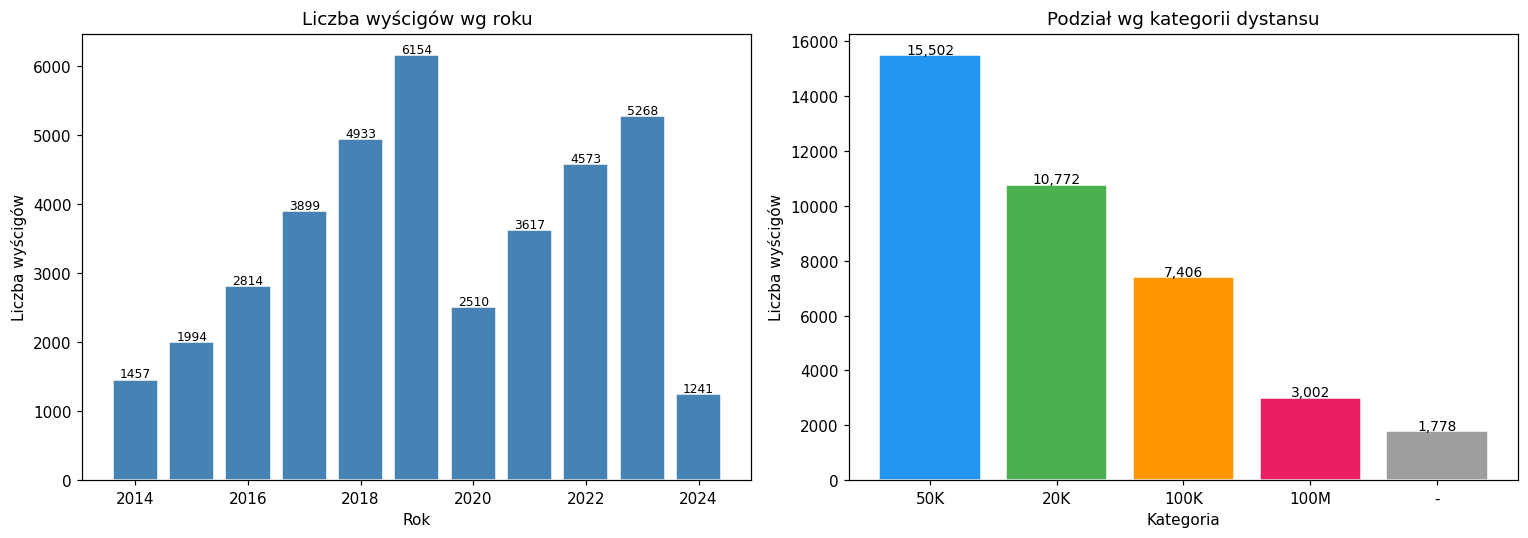

Wykres 1 zapisany


In [12]:

# --- Wizualizacja 1: Liczba wyścigów wg roku i kategorii ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# liczba wyścigów wg roku
races_per_year = df.groupby('Year').size()
axes[0].bar(races_per_year.index, races_per_year.values, color='steelblue', edgecolor='white')
axes[0].set_title('Liczba wyścigów wg roku')
axes[0].set_xlabel('Rok')
axes[0].set_ylabel('Liczba wyścigów')
for x, y in zip(races_per_year.index, races_per_year.values):
    axes[0].text(x, y + 30, str(y), ha='center', fontsize=8)

# kategorie wyścigów
cat_counts = df['Race Category'].value_counts()
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9E9E9E']
bars = axes[1].bar(cat_counts.index, cat_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Podział wg kategorii dystansu')
axes[1].set_xlabel('Kategoria')
axes[1].set_ylabel('Liczba wyścigów')
for bar, val in zip(bars, cat_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot1_year_category.png', bbox_inches='tight')
plt.show()
print("Wykres 1 zapisany")


In [13]:

# --- Wizualizacja 2: Rozkład dystansu i przewyższenia wg kategorii ---
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cats = ['20K', '50K', '100K', '100M']
palette = {'20K': '#2196F3', '50K': '#4CAF50', '100K': '#FF9800', '100M': '#E91E63'}

# dystans
df_cats = df[df['Race Category'].isin(cats)].copy()
df_cats.boxplot(column='Distance', by='Race Category', ax=axes[0],
                positions=[cats.index(c) for c in cats],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='navy', linewidth=2))
axes[0].set_title('Rozkład dystansu wg kategorii')
axes[0].set_xlabel('Kategoria')
axes[0].set_ylabel('Dystans [km]')
plt.sca(axes[0])
plt.xticks(range(4), cats)
axes[0].get_figure().suptitle('')

# przewyższenie
df_cats.boxplot(column='Elevation Gain', by='Race Category', ax=axes[1],
                positions=[cats.index(c) for c in cats],
                patch_artist=True,
                boxprops=dict(facecolor='lightgreen'),
                medianprops=dict(color='darkgreen', linewidth=2))
axes[1].set_title('Rozkład przewyższenia wg kategorii')
axes[1].set_xlabel('Kategoria')
axes[1].set_ylabel('Przewyższenie [m]')
plt.sca(axes[1])
plt.xticks(range(4), cats)

plt.tight_layout()
plt.savefig('plot2_dist_elev.png', bbox_inches='tight')
plt.show()


ModuleNotFoundError: No module named 'seaborn'

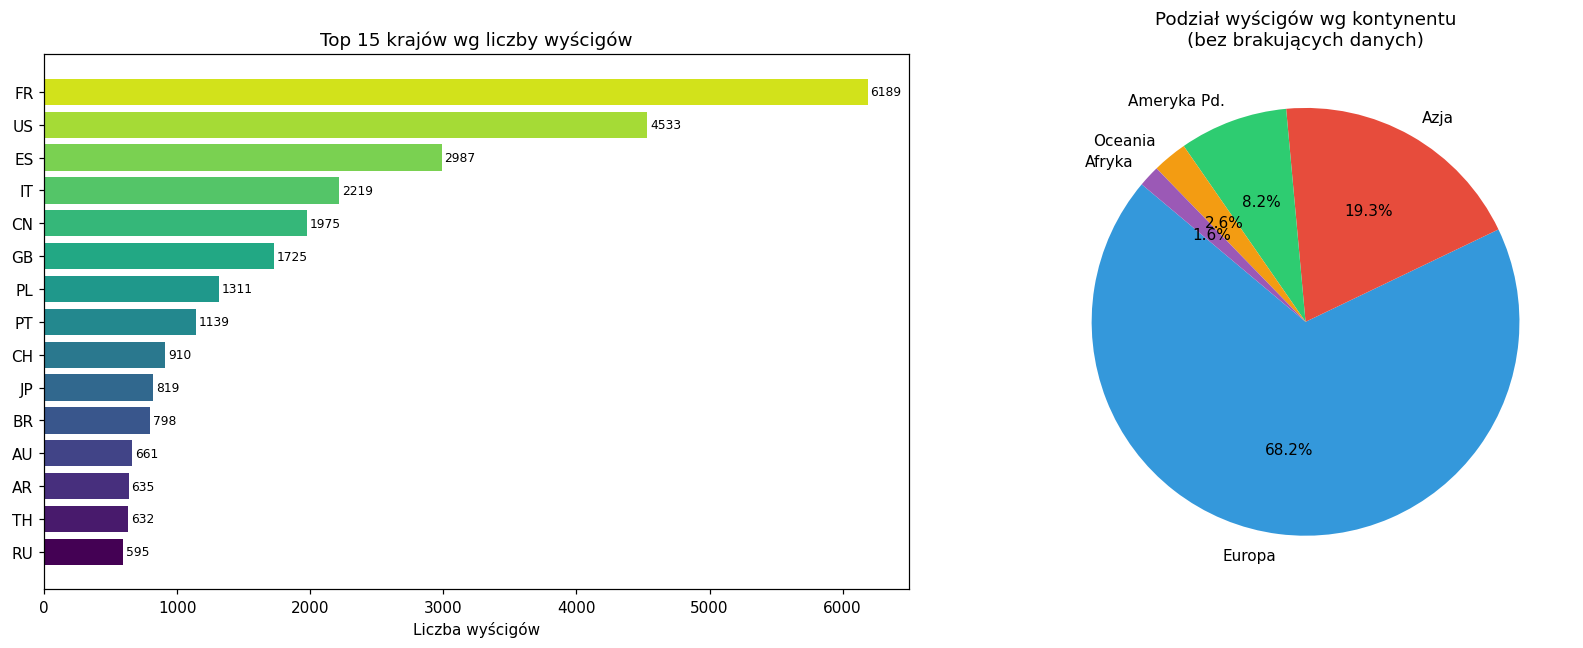

In [ ]:

# --- Wizualizacja 3: Top 15 krajów + rozkład według kontynentów ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# top 15 krajów
top_countries = df['Country'].value_counts().head(15)
colors_bar = plt.cm.viridis([i/15 for i in range(15)])
axes[0].barh(range(15), top_countries.values[::-1], color=colors_bar)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(top_countries.index[::-1])
axes[0].set_title('Top 15 krajów wg liczby wyścigów')
axes[0].set_xlabel('Liczba wyścigów')
for i, v in enumerate(top_countries.values[::-1]):
    axes[0].text(v + 20, i, str(v), va='center', fontsize=8)

# kontynenty (pie)
cont_counts = df['Continent'].value_counts()
cont_labels = {'EU': 'Europa', 'AS': 'Azja', 'NA': 'Ameryka Pn.', 
               'SA': 'Ameryka Pd.', 'OC': 'Oceania', 'AF': 'Afryka'}
labels = [cont_labels.get(c, c) for c in cont_counts.index]
wedge_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
axes[1].pie(cont_counts.values, labels=labels, autopct='%1.1f%%',
            colors=wedge_colors[:len(cont_counts)], startangle=140,
            textprops={'fontsize': 10})
axes[1].set_title('Podział wyścigów wg kontynentu\n(bez brakujących danych)')

plt.tight_layout()
plt.savefig('plot3_countries.png', bbox_inches='tight')
plt.show()


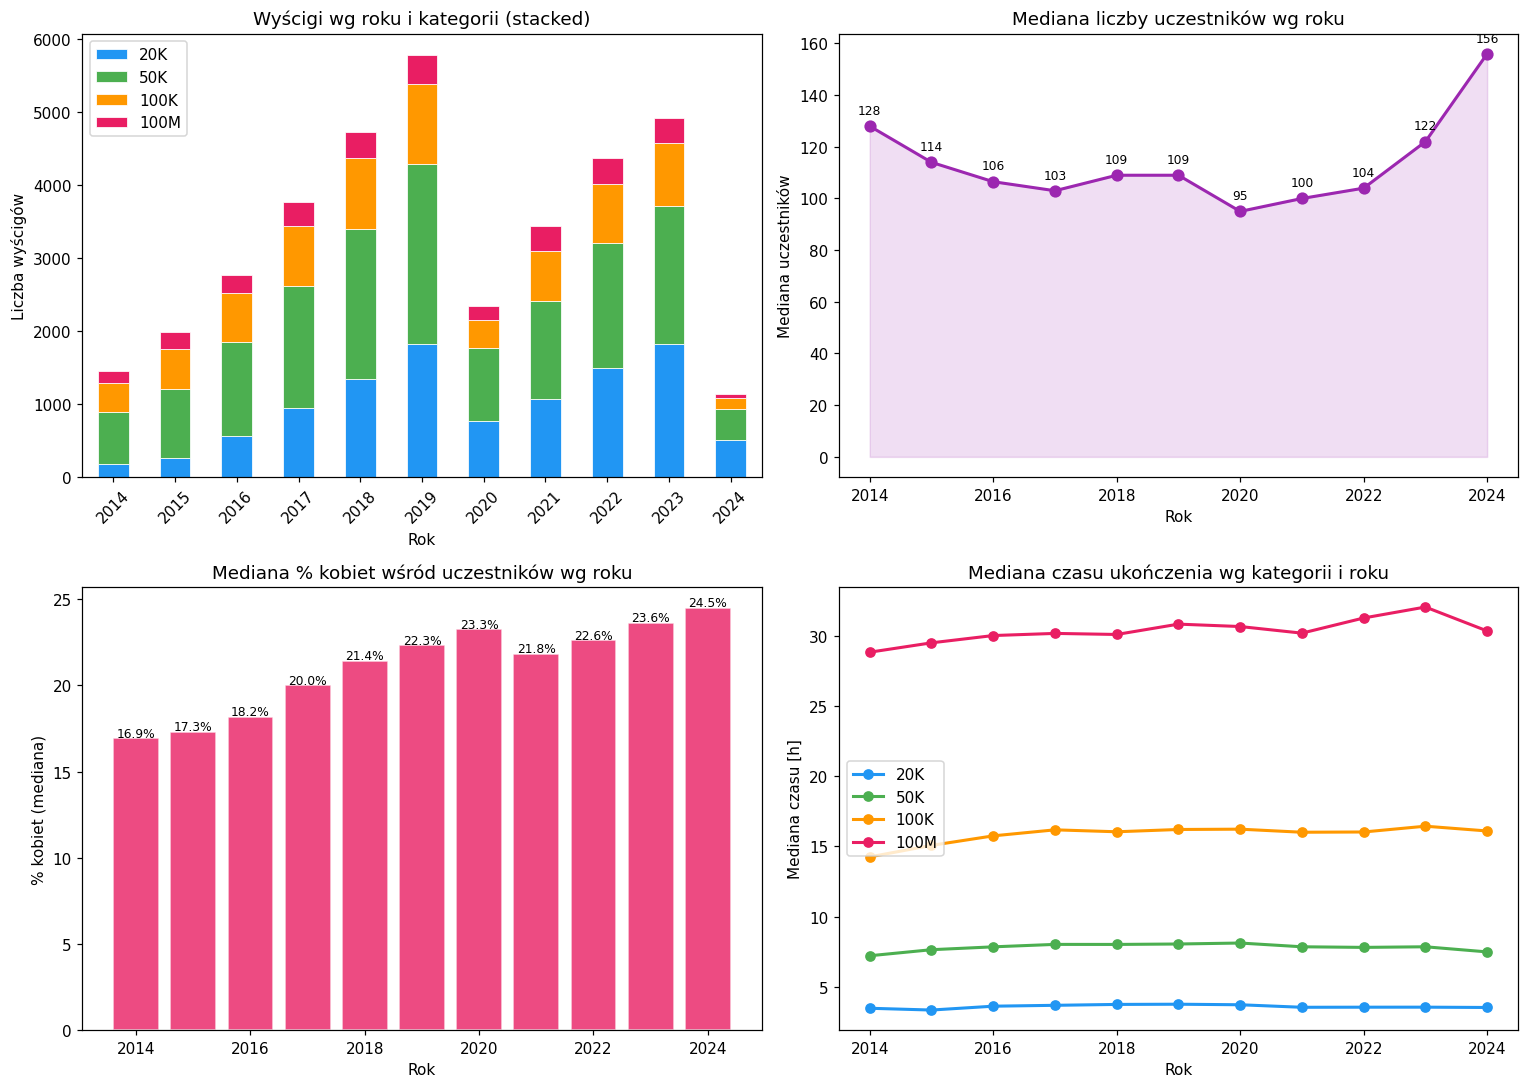

In [ ]:

# --- Wizualizacja 4: Trendy - wzrost ruchu trail runningowego w czasie ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# liczba wyścigów wg roku i kategorii (stacked)
cats_main = ['20K', '50K', '100K', '100M']
pivot_cat = df[df['Race Category'].isin(cats_main)].groupby(['Year', 'Race Category']).size().unstack(fill_value=0)
pivot_cat = pivot_cat.reindex(columns=cats_main)
pivot_cat.plot(kind='bar', stacked=True, ax=axes[0,0], 
               color=['#2196F3','#4CAF50','#FF9800','#E91E63'],
               edgecolor='white', linewidth=0.5)
axes[0,0].set_title('Wyścigi wg roku i kategorii (stacked)')
axes[0,0].set_xlabel('Rok')
axes[0,0].set_ylabel('Liczba wyścigów')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend(loc='upper left')

# mediana liczby uczestników wg roku
med_participants = df.groupby('Year')['N Participants'].median()
axes[0,1].plot(med_participants.index, med_participants.values, 'o-', color='#9C27B0', linewidth=2, markersize=7)
axes[0,1].fill_between(med_participants.index, med_participants.values, alpha=0.15, color='#9C27B0')
axes[0,1].set_title('Mediana liczby uczestników wg roku')
axes[0,1].set_xlabel('Rok')
axes[0,1].set_ylabel('Mediana uczestników')
for x, y in zip(med_participants.index, med_participants.values):
    axes[0,1].annotate(f'{y:.0f}', (x, y), textcoords="offset points", xytext=(0,8), ha='center', fontsize=8)

# % kobiet wg roku (mediana procent kobiet)
df['pct_women'] = df['N Women'] / df['N Participants'] * 100
med_women = df.groupby('Year')['pct_women'].median()
axes[1,0].bar(med_women.index, med_women.values, color='#E91E63', alpha=0.8, edgecolor='white')
axes[1,0].set_title('Mediana % kobiet wśród uczestników wg roku')
axes[1,0].set_xlabel('Rok')
axes[1,0].set_ylabel('% kobiet (mediana)')
for x, y in zip(med_women.index, med_women.values):
    axes[1,0].text(x, y + 0.1, f'{y:.1f}%', ha='center', fontsize=8)

# mediana czasu ukończenia wg kategorii i roku
df_cats = df[df['Race Category'].isin(cats_main)].dropna(subset=['Mean Finish Time'])
pivot_time = df_cats.groupby(['Year', 'Race Category'])['Mean Finish Time'].median().unstack()
pivot_time = pivot_time.reindex(columns=cats_main)
for cat, color in zip(cats_main, ['#2196F3','#4CAF50','#FF9800','#E91E63']):
    if cat in pivot_time.columns:
        axes[1,1].plot(pivot_time.index, pivot_time[cat], 'o-', label=cat, color=color, linewidth=2, markersize=6)
axes[1,1].set_title('Mediana czasu ukończenia wg kategorii i roku')
axes[1,1].set_xlabel('Rok')
axes[1,1].set_ylabel('Mediana czasu [h]')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('plot4_trends.png', bbox_inches='tight')
plt.show()


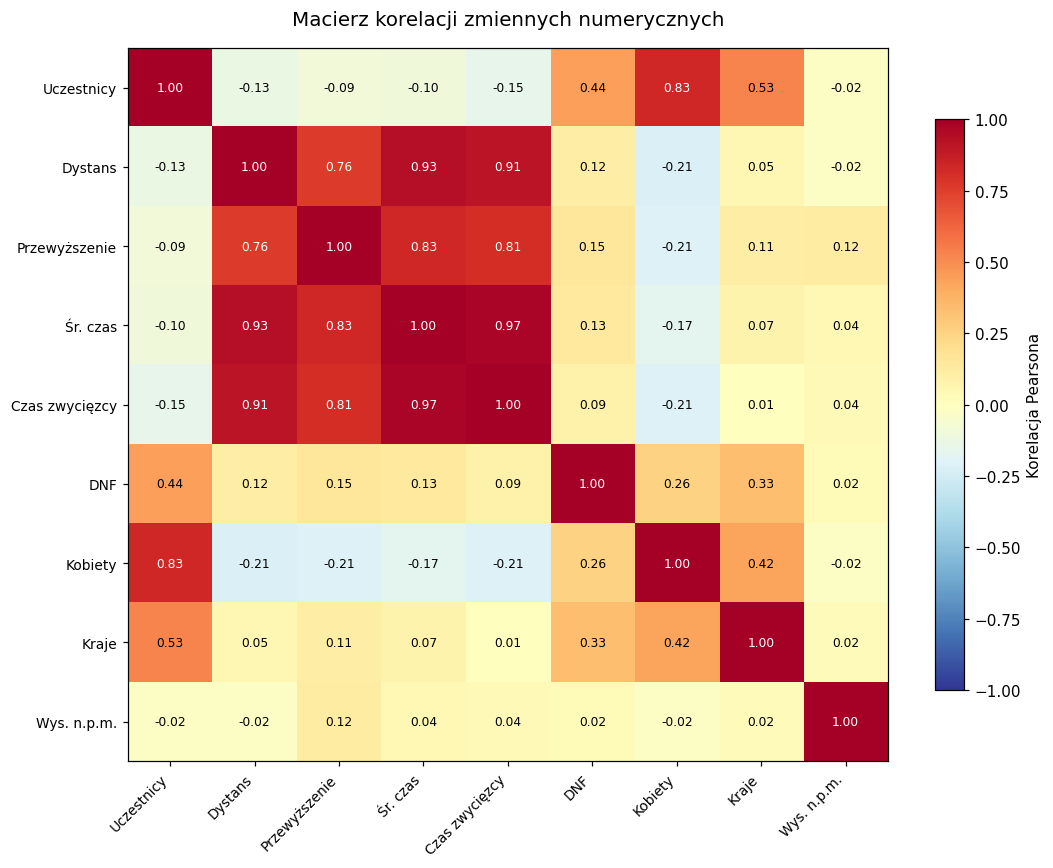

In [ ]:

# --- Wizualizacja 5: Korelacje między zmiennymi numerycznymi ---
import numpy as np

corr_cols = ['N Participants', 'Distance', 'Elevation Gain', 'Mean Finish Time',
             'Winning Time', 'N DNF', 'N Women', 'N Countries', 'Elevation']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = plt.cm.RdYlBu_r

im = ax.imshow(corr_matrix, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8, label='Korelacja Pearsona')

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
short_names = ['Uczestnicy', 'Dystans', 'Przewyższenie', 'Śr. czas', 
               'Czas zwycięzcy', 'DNF', 'Kobiety', 'Kraje', 'Wys. n.p.m.']
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(short_names, fontsize=9)

# wartości w komórkach
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = corr_matrix.iloc[i, j]
        color = 'white' if abs(v) > 0.6 else 'black'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8, color=color)

ax.set_title('Macierz korelacji zmiennych numerycznych', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('plot5_correlation.png', bbox_inches='tight')
plt.show()


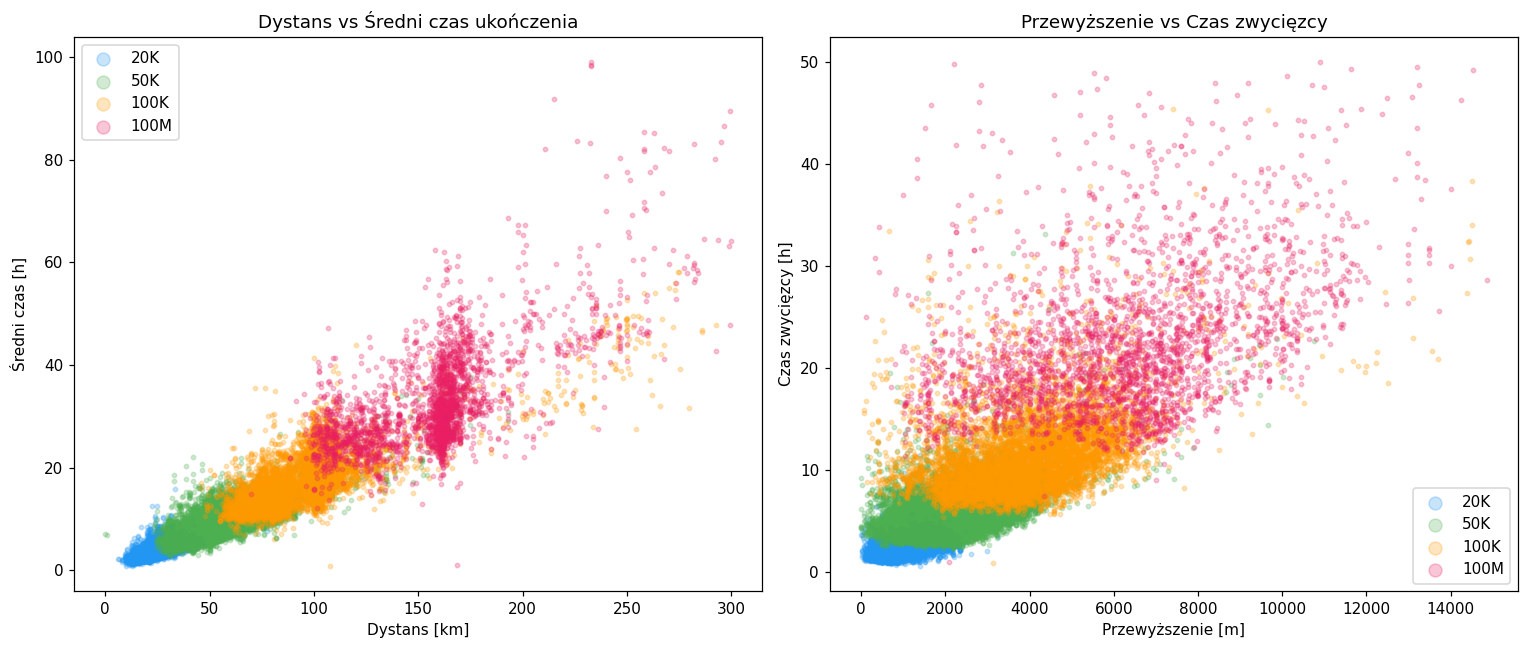

In [ ]:

# --- Wizualizacja 6: Scatter - dystans vs czas, pokolorowany kategorią ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cats_main = ['20K', '50K', '100K', '100M']
colors_cats = {'20K': '#2196F3', '50K': '#4CAF50', '100K': '#FF9800', '100M': '#E91E63'}

df_plot = df[df['Race Category'].isin(cats_main)].dropna(subset=['Mean Finish Time', 'Distance'])
# ogranicz outliers dla czytelności
df_plot = df_plot[(df_plot['Distance'] < 300) & (df_plot['Mean Finish Time'] < 100)]

for cat in cats_main:
    sub = df_plot[df_plot['Race Category'] == cat]
    axes[0].scatter(sub['Distance'], sub['Mean Finish Time'],
                    c=colors_cats[cat], alpha=0.25, s=8, label=cat)
axes[0].set_title('Dystans vs Średni czas ukończenia')
axes[0].set_xlabel('Dystans [km]')
axes[0].set_ylabel('Średni czas [h]')
axes[0].legend(markerscale=3)

# Scatter: przewyższenie vs czas zwycięzcy
df_plot2 = df_plot[(df_plot['Elevation Gain'] < 15000) & (df_plot['Winning Time'] < 50)]
for cat in cats_main:
    sub = df_plot2[df_plot2['Race Category'] == cat]
    axes[1].scatter(sub['Elevation Gain'], sub['Winning Time'],
                    c=colors_cats[cat], alpha=0.25, s=8, label=cat)
axes[1].set_title('Przewyższenie vs Czas zwycięzcy')
axes[1].set_xlabel('Przewyższenie [m]')
axes[1].set_ylabel('Czas zwycięzcy [h]')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.savefig('plot6_scatter.png', bbox_inches='tight')
plt.show()


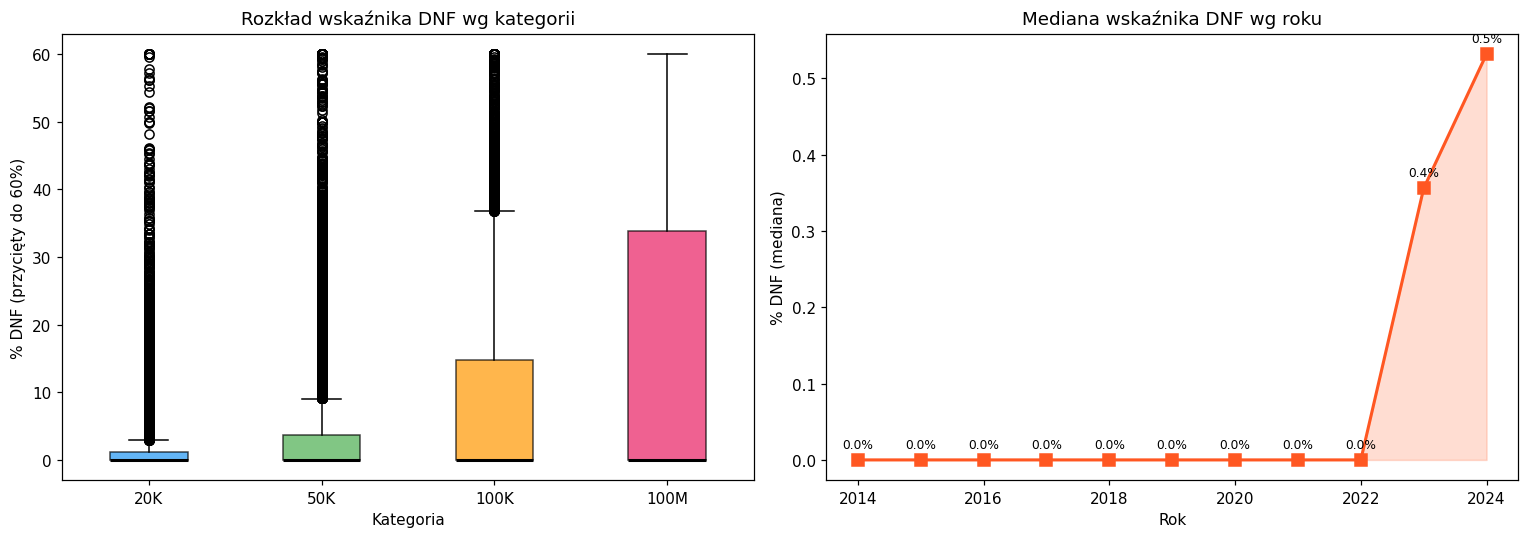

In [ ]:

# --- Wizualizacja 7: DNF rate - analiza rezygnacji wg kategorii ---
df['dnf_rate'] = df['N DNF'] / df['N Participants'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DNF rate wg kategorii
cats_main = ['20K', '50K', '100K', '100M']
dnf_by_cat = df[df['Race Category'].isin(cats_main)].groupby('Race Category')['dnf_rate']
positions = range(len(cats_main))
bplots = axes[0].boxplot([dnf_by_cat.get_group(c).dropna().clip(0, 60).values for c in cats_main],
                          positions=positions, patch_artist=True,
                          medianprops=dict(color='black', linewidth=2))
colors_list = ['#2196F3','#4CAF50','#FF9800','#E91E63']
for patch, color in zip(bplots['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_xticks(positions)
axes[0].set_xticklabels(cats_main)
axes[0].set_title('Rozkład wskaźnika DNF wg kategorii')
axes[0].set_xlabel('Kategoria')
axes[0].set_ylabel('% DNF (przycięty do 60%)')

# DNF rate wg roku (mediana)
dnf_by_year = df.groupby('Year')['dnf_rate'].median()
axes[1].plot(dnf_by_year.index, dnf_by_year.values, 's-', color='#FF5722', linewidth=2, markersize=8)
axes[1].fill_between(dnf_by_year.index, dnf_by_year.values, alpha=0.2, color='#FF5722')
axes[1].set_title('Mediana wskaźnika DNF wg roku')
axes[1].set_xlabel('Rok')
axes[1].set_ylabel('% DNF (mediana)')
for x, y in zip(dnf_by_year.index, dnf_by_year.values):
    axes[1].annotate(f'{y:.1f}%', (x, y), textcoords="offset points", xytext=(0,8), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('plot7_dnf.png', bbox_inches='tight')
plt.show()


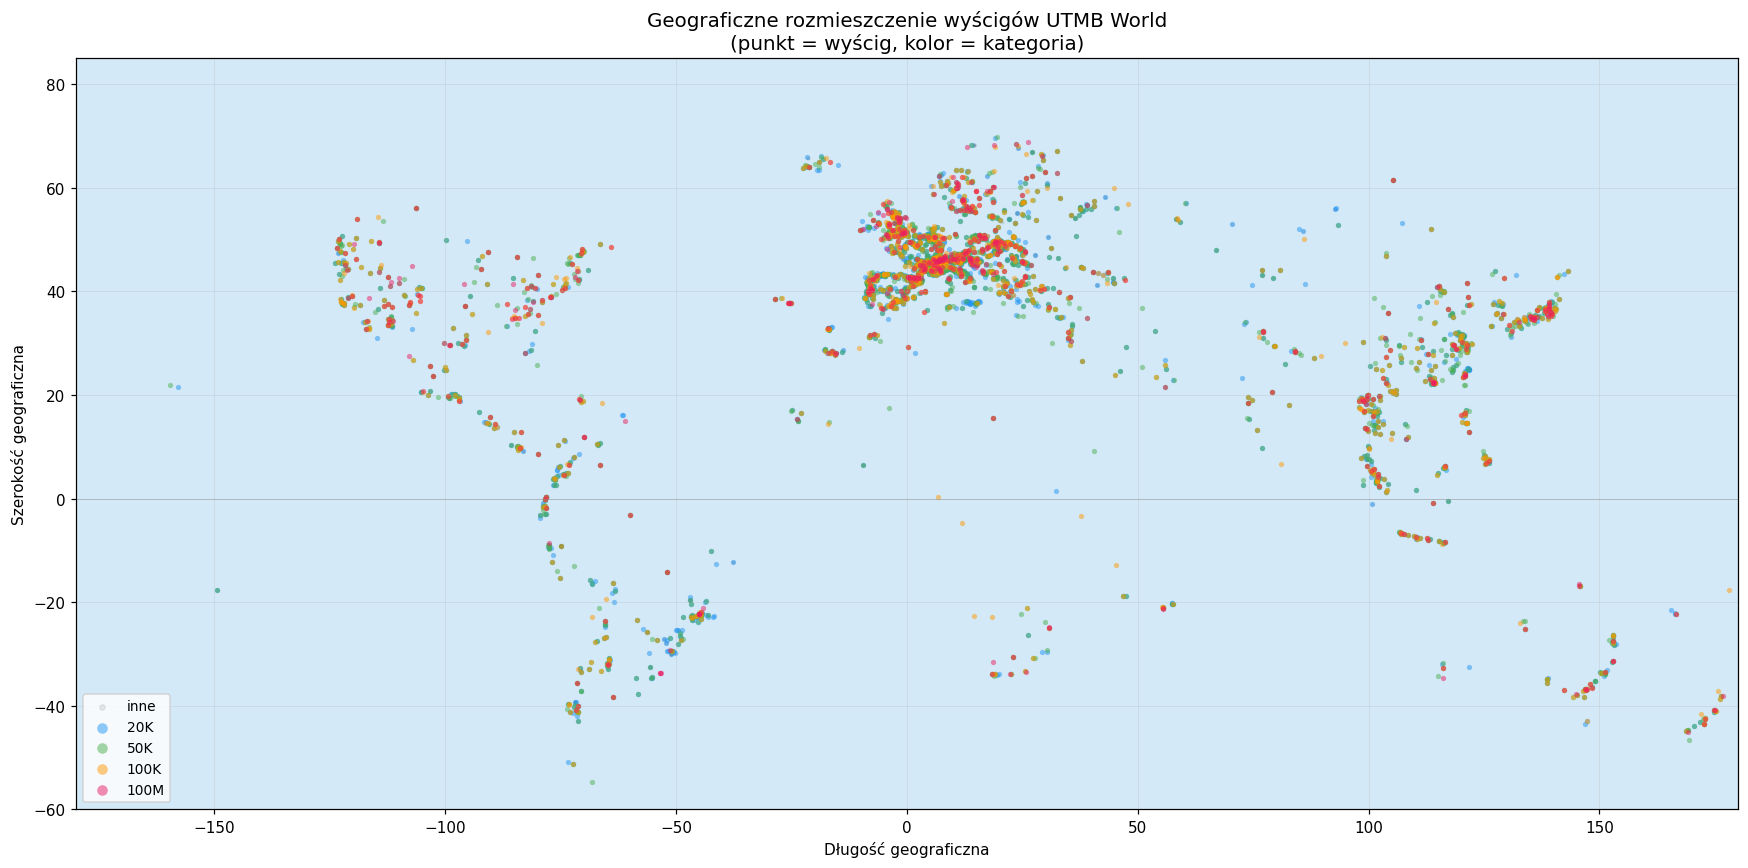

Unikalne lokalizacje na mapie: 3571


In [ ]:

# --- Wizualizacja 8: Mapa geograficzna wyścigów (rozrzut na mapie) ---
fig, ax = plt.subplots(figsize=(16, 8))

df_map = df.dropna(subset=['Longitude', 'Latitude'])
df_map = df_map[(df_map['Longitude'].between(-180, 180)) & (df_map['Latitude'].between(-90, 90))]

# tło mapy - siatka
ax.set_facecolor('#d4e9f7')
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.set_xlabel('Długość geograficzna')
ax.set_ylabel('Szerokość geograficzna')
ax.set_title('Geograficzne rozmieszczenie wyścigów UTMB World\n(punkt = wyścig, kolor = kategoria)', fontsize=13)
ax.grid(True, alpha=0.3, linewidth=0.5)

cats_main = ['20K', '50K', '100K', '100M']
colors_cats = {'20K': '#2196F3', '50K': '#4CAF50', '100K': '#FF9800', '100M': '#E91E63'}

# rysuj po kategoriach
other = df_map[~df_map['Race Category'].isin(cats_main)]
ax.scatter(other['Longitude'], other['Latitude'], c='gray', alpha=0.15, s=3, label='inne')

for cat in cats_main:
    sub = df_map[df_map['Race Category'] == cat]
    # weź unikalne lokalizacje
    sub_unique = sub.drop_duplicates(subset=['Longitude', 'Latitude'])
    ax.scatter(sub_unique['Longitude'], sub_unique['Latitude'],
               c=colors_cats[cat], alpha=0.5, s=12, label=cat, linewidths=0)

ax.legend(loc='lower left', markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig('plot8_map.png', bbox_inches='tight')
plt.show()
print(f"Unikalne lokalizacje na mapie: {df_map.drop_duplicates(subset=['Longitude','Latitude']).shape[0]}")


---
## Podsumowanie i wnioski z eksploracji danych

In [ ]:

# === PODSUMOWANIE EKSPLORACJI ===

print("=" * 60)
print("DATASET: UTMB World Race Data")
print("=" * 60)

print(f"\n📊 OGÓLNE INFORMACJE:")
print(f"  Wiersze:       {len(df):,}")
print(f"  Kolumny:       {df.shape[1]}")
print(f"  Zakres lat:    {df['Year'].min()} – {df['Year'].max()}")
print(f"  Krajów:        {df['Country'].nunique()}")
print(f"  Unikalnych wyścigów (Race UID): {df['Race UID'].nunique():,}")

print(f"\n📍 GEOGRAFIA:")
print(f"  Najbogatszy kraj: FR (Francja) — {df['Country'].value_counts().iloc[0]:,} wyścigów")
print(f"  Europa dominuje: {df[df['Continent']=='EU'].shape[0]/df.dropna(subset=['Continent']).shape[0]*100:.1f}% wyścigów")
print(f"  14.6% rekordów nie ma przypisanego kontynentu")

print(f"\n🏃 KATEGORIE DYSTANSU:")
for cat in ['20K','50K','100K','100M']:
    sub = df[df['Race Category']==cat]
    med_dist = sub['Distance'].median()
    med_time = sub['Mean Finish Time'].dropna().median()
    hh, mm = int(med_time), int((med_time % 1) * 60)
    print(f"  {cat}: {len(sub):,} wyścigów | mediana dystansu {med_dist:.0f} km | mediana czasu {hh}h {mm:02d}min")

print(f"\n👥 UCZESTNICY:")
print(f"  Mediana uczestników: {df['N Participants'].median():.0f}")
print(f"  Maks uczestników:    {df['N Participants'].max():,}")
print(f"  Mediana % kobiet (2014→2024): {df[df['Year']==2014]['pct_women'].median():.1f}% → {df[df['Year']==2024]['pct_women'].median():.1f}%")

print(f"\n📈 TRENDY:")
print(f"  Wzrost wyścigów 2014→2019: {df[df['Year']==2014].shape[0]:,} → {df[df['Year']==2019].shape[0]:,} (+{(df[df['Year']==2019].shape[0]/df[df['Year']==2014].shape[0]-1)*100:.0f}%)")
print(f"  Spadek 2019→2020 (COVID): {df[df['Year']==2019].shape[0]:,} → {df[df['Year']==2020].shape[0]:,}")
print(f"  Odbudowa 2023: {df[df['Year']==2023].shape[0]:,} wyścigów")

print(f"\n🔗 KORELACJE (kluczowe):")
corr = df[['Distance','Elevation Gain','Mean Finish Time','Winning Time','N Participants','N Women']].corr()
print(f"  Dystans ↔ Śr. czas:          r = {corr.loc['Distance','Mean Finish Time']:.2f}")
print(f"  Przewyższenie ↔ Śr. czas:     r = {corr.loc['Elevation Gain','Mean Finish Time']:.2f}")
print(f"  Uczestnicy ↔ Kobiety:         r = {corr.loc['N Participants','N Women']:.2f}")
print(f"  Dystans ↔ Czas zwycięzcy:     r = {corr.loc['Distance','Winning Time']:.2f}")


DATASET: UTMB World Race Data

📊 OGÓLNE INFORMACJE:
  Wiersze:       38,460
  Kolumny:       24
  Zakres lat:    2014 – 2024
  Krajów:        126
  Unikalnych wyścigów (Race UID): 15,679

📍 GEOGRAFIA:
  Najbogatszy kraj: FR (Francja) — 6,189 wyścigów
  Europa dominuje: 68.2% wyścigów
  14.6% rekordów nie ma przypisanego kontynentu

🏃 KATEGORIE DYSTANSU:
  20K: 10,772 wyścigów | mediana dystansu 24 km | mediana czasu 3h 36min
  50K: 15,502 wyścigów | mediana dystansu 50 km | mediana czasu 7h 51min
  100K: 7,406 wyścigów | mediana dystansu 92 km | mediana czasu 15h 57min
  100M: 3,002 wyścigów | mediana dystansu 161 km | mediana czasu 30h 22min

👥 UCZESTNICY:
  Mediana uczestników: 110
  Maks uczestników:    6,740
  Mediana % kobiet (2014→2024): 16.9% → 24.5%

📈 TRENDY:
  Wzrost wyścigów 2014→2019: 1,457 → 6,154 (+322%)
  Spadek 2019→2020 (COVID): 6,154 → 2,510
  Odbudowa 2023: 5,268 wyścigów

🔗 KORELACJE (kluczowe):
  Dystans ↔ Śr. czas:          r = 0.93
  Przewyższenie ↔ Śr. czas:    